# Exploratory Data Analysis — Credit Card Fraud Detection

Before building any preprocessing or training logic, we look at the raw data directly.
This notebook answers:
1. How big is the dataset, and are there any missing/duplicate rows?
2. How imbalanced is fraud vs. not-fraud?
3. What does the `Amount` distribution look like for fraud vs. legitimate transactions?
4. How does `Time` relate to fraud — are frauds clustered at certain hours?
5. Which V1-V28 features separate fraud from non-fraud most clearly?

These answers are exactly what justified the choices baked into `params.yaml`
(scaling Amount/Time, using SMOTE, picking Random Forest).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Basic data quality checks

In [2]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total nulls")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes.value_counts())

Missing values per column:
0 total nulls

Duplicate rows: 1081

Data types:
float64    30
int64       1
Name: count, dtype: int64


## 2. Class imbalance — the core challenge of this dataset

Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentages:
 Class
0    99.827
1     0.173
Name: proportion, dtype: float64


C:\Users\Sumaiya Chan\AppData\Local\Temp\ipykernel_4672\1185985409.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not Fraud (0)", "Fraud (1)"])


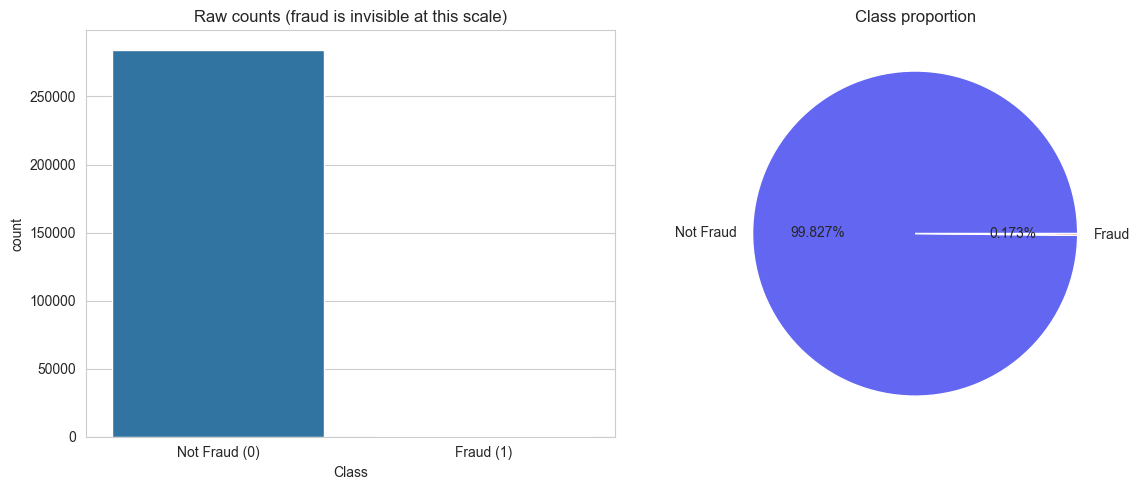


This is WHY we use SMOTE in preprocessing -- without it, a model
could predict 'not fraud' for everyone and still score ~99.8% accuracy.


In [3]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Counts:\n", class_counts)
print("\nPercentages:\n", class_pct.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Class", data=df, ax=axes[0])
axes[0].set_title("Raw counts (fraud is invisible at this scale)")
axes[0].set_xticklabels(["Not Fraud (0)", "Fraud (1)"])

axes[1].pie(class_counts, labels=["Not Fraud", "Fraud"], autopct="%1.3f%%",
            colors=["#6366f1", "#ef4444"])
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.show()

print("\nThis is WHY we use SMOTE in preprocessing -- without it, a model")
print("could predict 'not fraud' for everyone and still score ~99.8% accuracy.")

## 3. Transaction Amount — fraud vs. legitimate

Amount stats for NOT fraud:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Amount stats for FRAUD:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


C:\Users\Sumaiya Chan\AppData\Local\Temp\ipykernel_4672\1691577983.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not Fraud", "Fraud"])
C:\Users\Sumaiya Chan\AppData\Local\Temp\ipykernel_4672\1691577983.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not Fraud", "Fraud"])


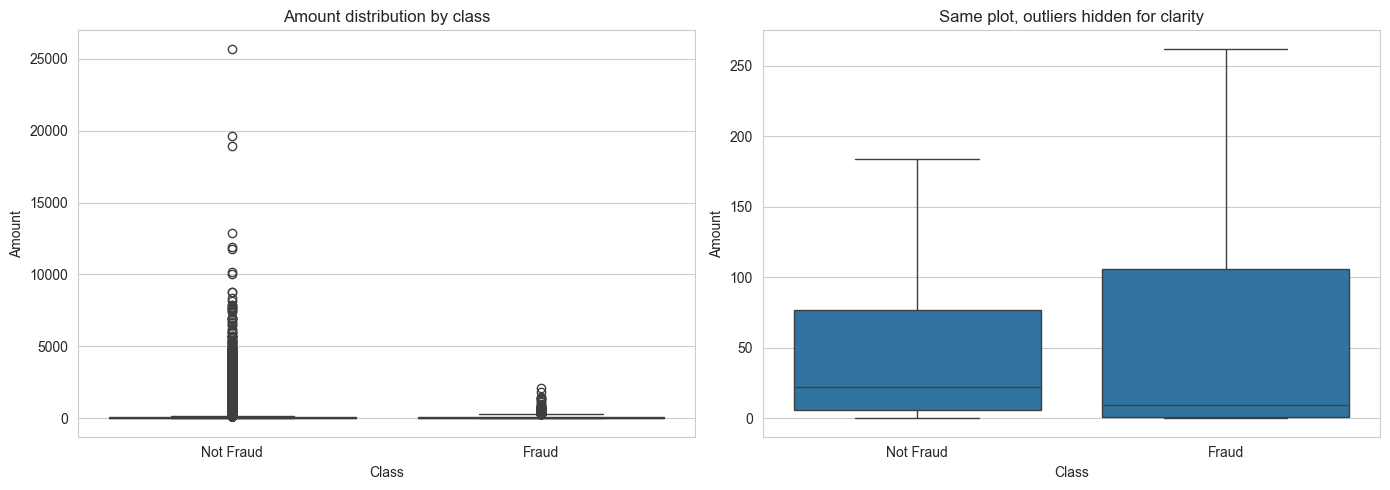


This is WHY we scale Amount in preprocessing -- it has a very
different range/spread than the already-PCA-scaled V1-V28 columns.


In [4]:
print("Amount stats for NOT fraud:")
print(df[df["Class"] == 0]["Amount"].describe())

print("\nAmount stats for FRAUD:")
print(df[df["Class"] == 1]["Amount"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0])
axes[0].set_title("Amount distribution by class")
axes[0].set_xticklabels(["Not Fraud", "Fraud"])

# Zoomed in version, since a few huge legitimate outliers squash the boxplot
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1], showfliers=False)
axes[1].set_title("Same plot, outliers hidden for clarity")
axes[1].set_xticklabels(["Not Fraud", "Fraud"])

plt.tight_layout()
plt.show()

print("\nThis is WHY we scale Amount in preprocessing -- it has a very")
print("different range/spread than the already-PCA-scaled V1-V28 columns.")

## 4. Time — are frauds clustered at certain points?

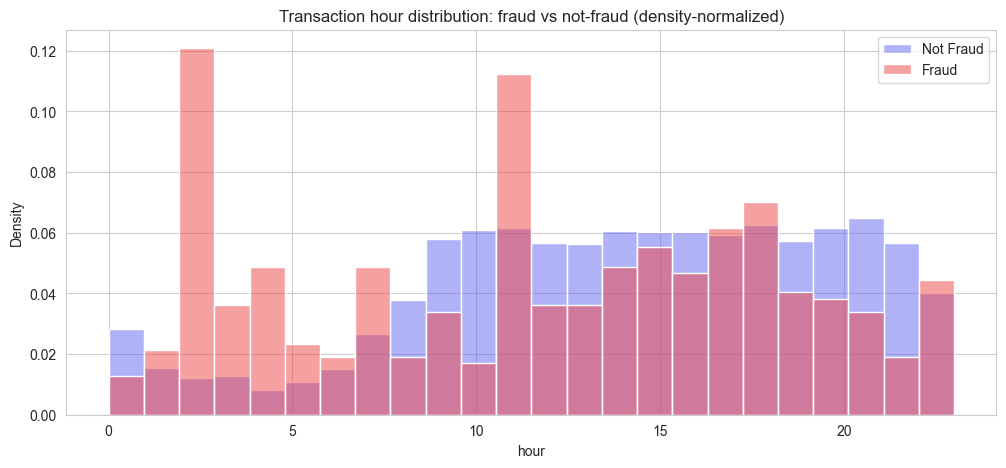

In [5]:
# Time is seconds elapsed since the first transaction, across ~2 days.
# Convert to "hour of the (combined) day" for an easier-to-read view.
df["hour"] = (df["Time"] // 3600) % 24

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df[df["Class"] == 0], x="hour", bins=24, stat="density",
             color="#6366f1", alpha=0.5, label="Not Fraud", ax=ax)
sns.histplot(data=df[df["Class"] == 1], x="hour", bins=24, stat="density",
             color="#ef4444", alpha=0.5, label="Fraud", ax=ax)
ax.set_title("Transaction hour distribution: fraud vs not-fraud (density-normalized)")
ax.legend()
plt.show()

df = df.drop(columns=["hour"])  # was only for this plot, not used downstream

## 5. Which V1-V28 features separate fraud most clearly?

These are anonymized PCA components, so we can't say what they *mean*,
but we can see which ones differ most between classes -- useful context
for trusting (or questioning) what the trained model leans on.

Top 10 features by mean difference (fraud vs not-fraud):
V3    -7.045452
V14   -6.983787
V17   -6.677371
V12   -6.270225
V10   -5.686707
V7    -5.578368
V1    -4.780206
V4     4.549889
V16   -4.147110
V11    3.806749
dtype: float64


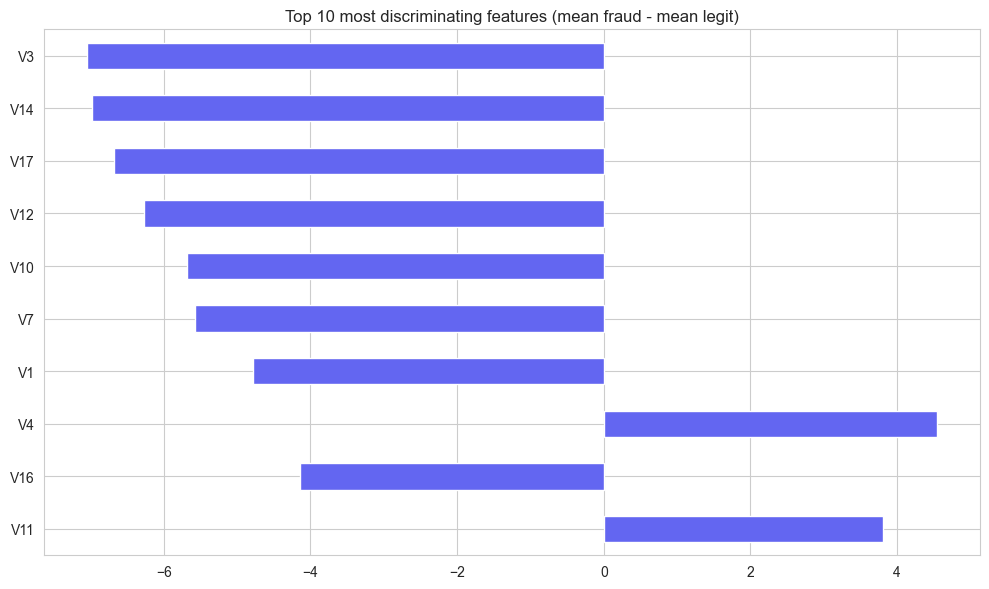

In [6]:
v_cols = [c for c in df.columns if c.startswith("V")]

# Mean difference between fraud and non-fraud for each V column
means_fraud = df[df["Class"] == 1][v_cols].mean()
means_legit = df[df["Class"] == 0][v_cols].mean()
diff = (means_fraud - means_legit).sort_values(key=abs, ascending=False)

print("Top 10 features by mean difference (fraud vs not-fraud):")
print(diff.head(10))

fig, ax = plt.subplots(figsize=(10, 6))
diff.head(10).plot(kind="barh", ax=ax, color="#6366f1")
ax.set_title("Top 10 most discriminating features (mean fraud - mean legit)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Correlation heatmap (top discriminating features only)

Full 30x30 heatmap is noisy and slow to read -- we focus on the
top features identified above, plus Amount, Time, and Class.

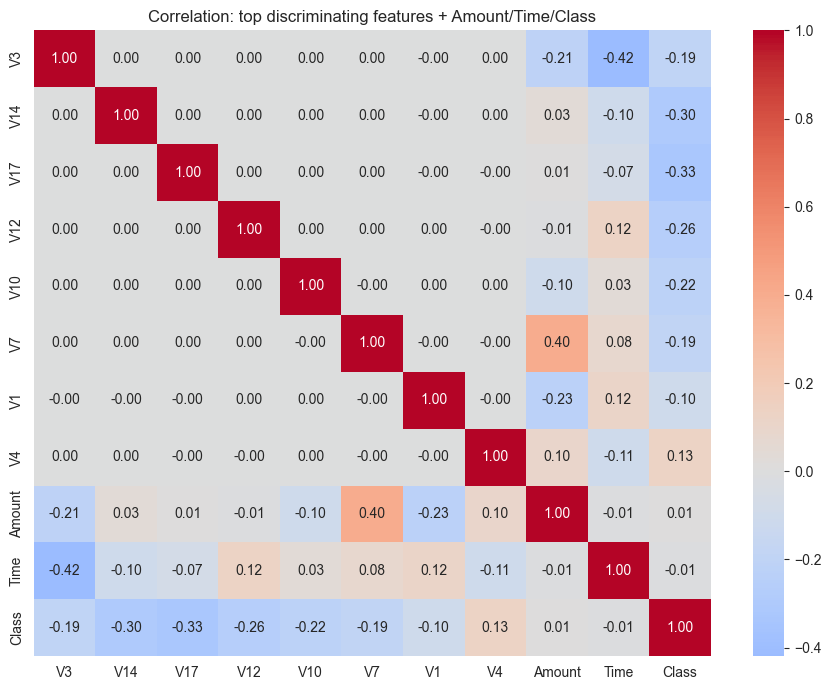

In [7]:
top_features = diff.head(8).index.tolist() + ["Amount", "Time", "Class"]

corr = df[top_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: top discriminating features + Amount/Time/Class")
plt.tight_layout()
plt.show()

## Summary of findings

- **284,807 transactions, 492 fraud (~0.17%)** — extreme class imbalance confirmed.
  This justifies using SMOTE (or another balancing method) during preprocessing,
  and using precision/recall/ROC-AUC instead of accuracy for evaluation.
- **No missing values**, some duplicate rows exist and are dropped in preprocessing.
- **Amount and Time** are on very different scales than the PCA-transformed
  V1-V28 columns, which is why they get standard-scaled separately.
- **A handful of V-columns** (see section 5) show a clear mean separation
  between fraud and legitimate transactions — these likely drive most of
  the trained model's decisions, even though we can't know their real-world
  meaning due to the PCA anonymization.

Next step: `src/data_preprocessing.py` and `src/data_training.py` (or simply `python main.py`).